In [8]:
#Fashion-MNIST data exploration

#pupose of notebook is to load fashion dataset, check the dataset shape, visualizes sample images, 
#and prepare the data for ML classifiers

In [9]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# load Fashion-MNIST from OpenML
fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False)

X = fashion.data
y = fashion.target.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


In [11]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [12]:
#changing image brightness values inside X to 0 or 1
#0 = black; 255 = white
X = X / 255.0

In [13]:
#split data
from sklearn.model_selection import train_test_split

#making training/validation/test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=10000,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=10000,
    random_state=42,
    stratify=y_train_val
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (50000, 784)
Validation set: (10000, 784)
Test set: (10000, 784)


In [14]:
#train logistic regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# train logistic regression model
log_reg = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="lbfgs",
    multi_class="auto",
    random_state=42
)

log_reg.fit(X_train, y_train)

# evaluate on validation set
y_val_pred = log_reg.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation accuracy:", val_accuracy)

/Users/christineoladapo/miniconda3/envs/cs178/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Validation accuracy: 0.8532


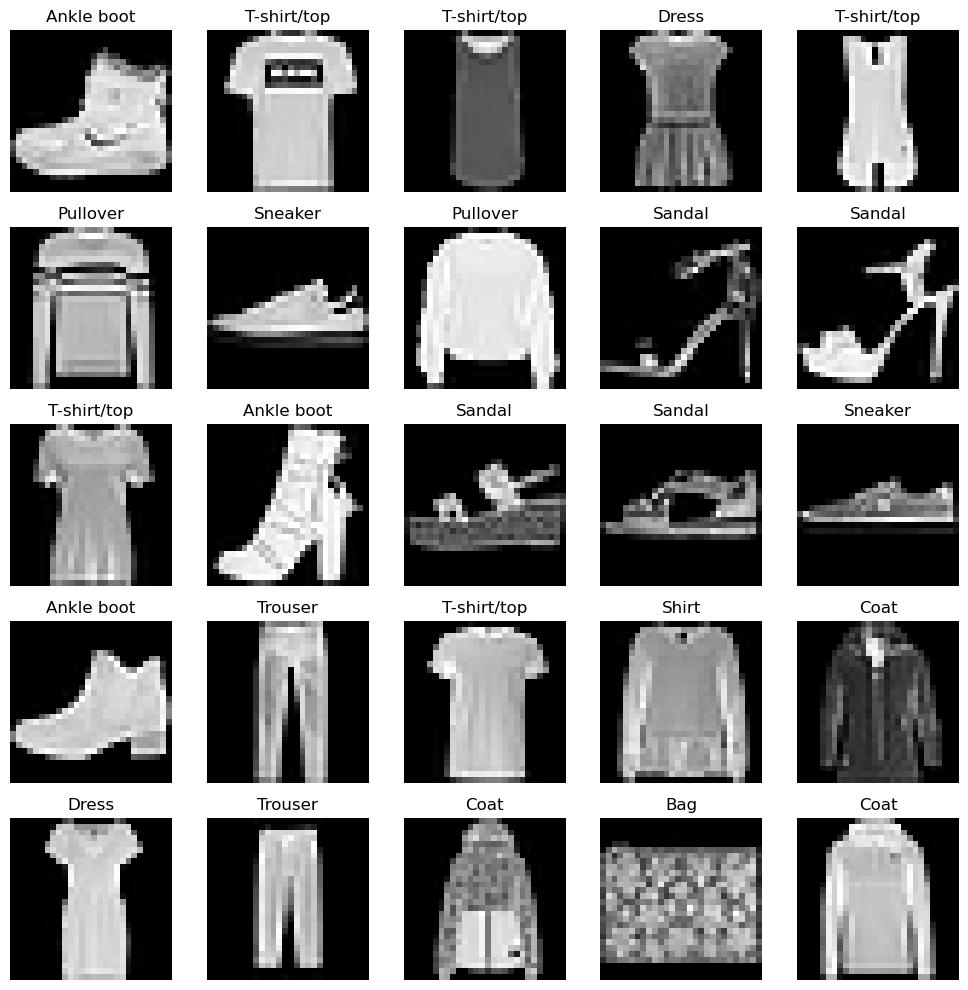

In [18]:
#for data exploration

# display sample Fashion-MNIST images
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(class_names[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

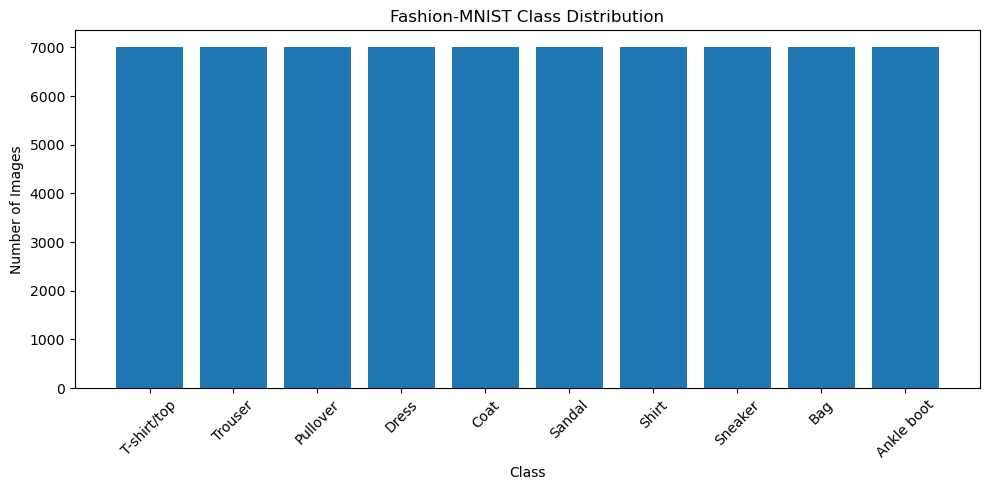

T-shirt/top : 7000
Trouser : 7000
Pullover : 7000
Dress : 7000
Coat : 7000
Sandal : 7000
Shirt : 7000
Sneaker : 7000
Bag : 7000
Ankle boot : 7000


In [19]:
#class distributionc hart for data description
# count number of examples in each class
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Fashion-MNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

for label, count in zip(unique, counts):
    print(class_names[label], ":", count)

In [16]:
#small C = stronger regular.
#large C = weaker regular.

C_values = [0.01, 0.1, 1, 10]

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, solver="lbfgs", random_state=42)

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    print("C =", C, "Validation accuracy:", val_accuracy)

C = 0.01 Validation accuracy: 0.8506
C = 0.1 Validation accuracy: 0.8577
C = 1 Validation accuracy: 0.8532
C = 10 Validation accuracy: 0.8468


/Users/christineoladapo/miniconda3/envs/cs178/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Final test accuracy: 0.8552


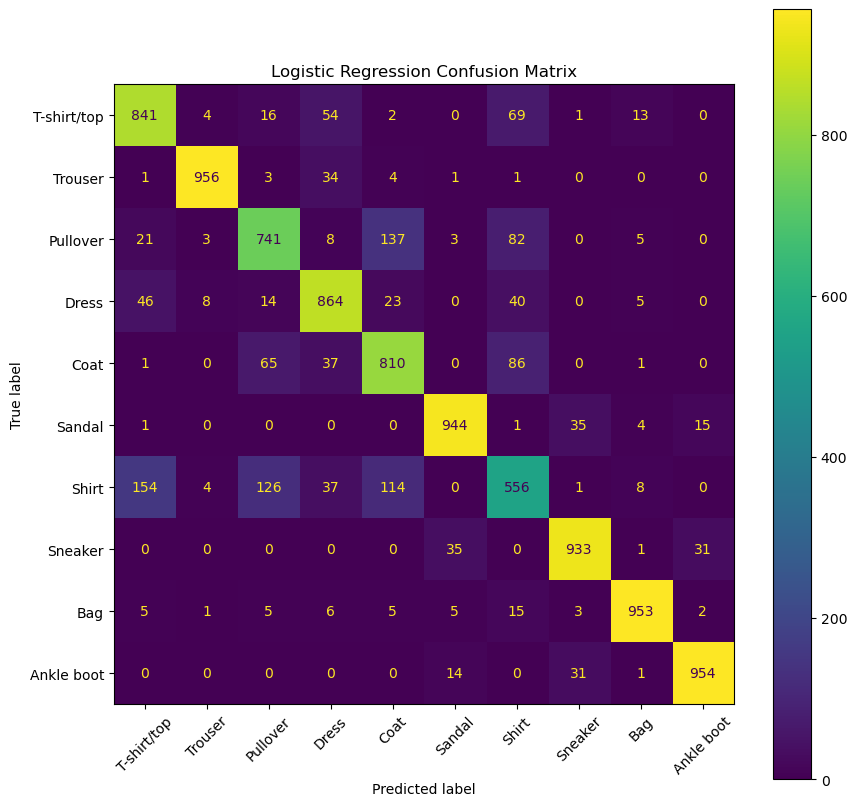

In [17]:
#confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# train final logistic regression model using best C value
best_log_reg = LogisticRegression(
    C=0.1,
    max_iter=2000,
    solver="lbfgs",
    random_state=42
)

best_log_reg.fit(X_train, y_train)

# create predictions on the test set
y_test_pred = best_log_reg.predict(X_test)

# calculate test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Final test accuracy:", test_accuracy)





cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.show()